# ДЗ 6. MHLA
Линейное внимание даёт $O(N)$, но сжимает контекст. MHLA делит токены на $M$ блоков, добавляет обучаемую матрицу смешивания $M\times M$, поднимает потолок ранга до $\min(N, M\cdot d_h)$

### Конфиг

In [19]:
import time
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

CONFIG = dict(
    dim=192,
    depth=4,
    patch_size=4,
    image_size=32,
    n_blocks=16,
    n_heads=6,
    mlp_ratio=2.0,
    epochs=15,
    batch_size=128,
    lr=1e-3,
    weight_decay=0.05,
    num_classes=10,
)
CONFIG["n_patches"] = (CONFIG["image_size"] // CONFIG["patch_size"]) ** 2
device, CONFIG

('cuda',
 {'dim': 192,
  'depth': 4,
  'patch_size': 4,
  'image_size': 32,
  'n_blocks': 16,
  'n_heads': 6,
  'mlp_ratio': 2.0,
  'epochs': 15,
  'batch_size': 128,
  'lr': 0.001,
  'weight_decay': 0.05,
  'num_classes': 10,
  'n_patches': 64})

In [20]:
# !pip install -q torch torchvision matplotlib numpy

import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

### Механизмы attention

In [21]:
def phi(x):
    return F.elu(x) + 1.0


class SoftmaxAttention(nn.Module):
    def __init__(self, dim, n_heads=6, **kwargs):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

    @torch.no_grad()
    def attention_matrix(self, x, per_head=False):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k = qkv[0], qkv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        return attn if per_head else attn.mean(dim=1)

In [22]:
class VanillaLinearAttention(nn.Module):
    def __init__(self, dim, n_heads=6, eps=1e-6, **kwargs):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.eps = eps
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q, k = phi(q), phi(k)
        kv = torch.einsum("bhnd,bhne->bhde", k, v)
        z = k.sum(dim=2)
        num = torch.einsum("bhnd,bhde->bhne", q, kv)
        den = torch.einsum("bhnd,bhd->bhn", q, z).clamp_min(self.eps)
        out = num / den.unsqueeze(-1)
        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

    @torch.no_grad()
    def attention_matrix(self, x, per_head=False):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k = phi(qkv[0]), phi(qkv[1])
        scores = torch.einsum("bhid,bhjd->bhij", q, k)
        attn = scores / scores.sum(dim=-1, keepdim=True).clamp_min(self.eps)
        return attn if per_head else attn.mean(dim=1)

### MHLA. Token-level multi-head

In [23]:
class MHLA(nn.Module):
    def __init__(self, dim, n_heads=6, n_blocks=16, eps=1e-6, locality_init=True,
                 row_softmax=True, **kwargs):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.M = n_blocks
        self.eps = eps
        self.row_softmax = row_softmax
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

        if locality_init:
            idx = torch.arange(self.M).float()
            dist = (idx[:, None] - idx[None, :]).abs()
            init = 1.0 - dist / dist.max()
        else:
            init = torch.ones(self.M, self.M)
        self.mixing = nn.Parameter(init)

    def mixing_matrix(self):
        return F.softmax(self.mixing, dim=-1) if self.row_softmax else self.mixing

    def _blockify(self, t, N):
        pad = (-N) % self.M
        if pad:
            t = F.pad(t, (0, 0, 0, pad))
        Np = t.shape[2]
        nb = Np // self.M
        return t.reshape(t.shape[0], self.n_heads, self.M, nb, self.head_dim), pad

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q, k = phi(q), phi(k)

        qb, _ = self._blockify(q, N)
        kb, _ = self._blockify(k, N)
        vb, pad = self._blockify(v, N)

        S = torch.einsum("bhmnd,bhmne->bhmde", kb, vb)
        z = kb.sum(dim=3)

        Mc = self.mixing_matrix()
        S_mix = torch.einsum("ij,bhjde->bhide", Mc, S)
        z_mix = torch.einsum("ij,bhjd->bhid", Mc, z)

        num = torch.einsum("bhmnd,bhmde->bhmne", qb, S_mix)
        den = torch.einsum("bhmnd,bhmd->bhmn", qb, z_mix).clamp_min(self.eps)
        out = num / den.unsqueeze(-1)

        out = out.reshape(B, self.n_heads, -1, self.head_dim)
        if pad:
            out = out[:, :, :N]
        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

    @torch.no_grad()
    def attention_matrix(self, x, per_head=False):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k = phi(qkv[0]), phi(qkv[1])
        pad = (-N) % self.M
        Np = N + pad
        nb = Np // self.M
        block_of = torch.arange(Np, device=x.device) // nb
        Mc = self.mixing_matrix()
        gate = Mc[block_of][:, block_of]
        gate = gate[:N, :N]
        scores = torch.einsum("bhid,bhjd->bhij", q, k) * gate
        attn = scores / scores.sum(dim=-1, keepdim=True).clamp_min(self.eps)
        return attn if per_head else attn.mean(dim=1)


ATTENTIONS = {"softmax": SoftmaxAttention, "linear": VanillaLinearAttention, "mhla": MHLA}

### тест MHLA с единичной матрицей смешивания, получаем линейное внимание

In [24]:
def _mhla_equals_linear():
    set_seed(0)
    x = torch.randn(2, 16, 24)
    lin = VanillaLinearAttention(24, n_heads=3)
    mhla = MHLA(24, n_heads=3, n_blocks=4, locality_init=False, row_softmax=False)
    mhla.load_state_dict(lin.state_dict(), strict=False)
    with torch.no_grad():
        diff = (lin(x) - mhla(x)).abs().max().item()
    print(f"max|linear - MHLA(ones)| = {diff:.2e}")
    assert diff < 1e-5, "MHLA с единичным смешиванием должно совпадать с линейным вниманием"

_mhla_equals_linear()

max|linear - MHLA(ones)| = 5.96e-08


### Vit

In [25]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, attn, mlp_ratio):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = attn
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):
    def __init__(self, attn_type, cfg):
        super().__init__()
        dim = cfg["dim"]
        self.patch_embed = nn.Conv2d(3, dim, kernel_size=cfg["patch_size"], stride=cfg["patch_size"])
        n = cfg["n_patches"]
        self.pos_embed = nn.Parameter(torch.zeros(1, n, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        attn_cls = ATTENTIONS[attn_type]
        self.blocks = nn.ModuleList([
            TransformerBlock(
                dim,
                attn_cls(dim, n_heads=cfg["n_heads"], n_blocks=cfg["n_blocks"]),
                cfg["mlp_ratio"],
            )
            for _ in range(cfg["depth"])
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, cfg["num_classes"])

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x).mean(dim=1)
        return self.head(x)


def count_params(m):
    return sum(p.numel() for p in m.parameters())

for name in ATTENTIONS:
    print(f"{name:8s}  params = {count_params(ViT(name, CONFIG)):,}")

softmax   params = 1,212,106
linear    params = 1,212,106
mhla      params = 1,213,130


### CIFAR-10

50k train / 10k test, 32×32, 10 классов, случайный кроп, флип.

In [ ]:
import torchvision.datasets.cifar as _cifar_mod
_cifar_mod.check_integrity = lambda *a, **k: True

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])

train_set = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_tf)
test_set = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_tf)

pin = device == "cuda"
train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True,
                          num_workers=2, pin_memory=pin, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=pin)
len(train_set), len(test_set)

(50000, 10000)

### Обучение трёх вариантов

In [27]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    top1 = top5 = total = 0
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        _, pred5 = logits.topk(5, dim=1)
        correct = pred5.eq(yb.unsqueeze(1))
        top1 += correct[:, 0].sum().item()
        top5 += correct.any(dim=1).sum().item()
        total += yb.size(0)
    return top1 / total, top5 / total


def train_variant(attn_type, cfg):
    set_seed(42)
    model = ViT(attn_type, cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "train_acc": [], "val_top1": [], "val_top5": [], "epoch_time": []}

    for epoch in range(cfg["epochs"]):
        model.train()
        t0 = time.time()
        run_loss = correct = seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            run_loss += loss.item() * yb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            seen += yb.size(0)
        sched.step()
        val1, val5 = evaluate(model)
        hist["train_loss"].append(run_loss / seen)
        hist["train_acc"].append(correct / seen)
        hist["val_top1"].append(val1)
        hist["val_top5"].append(val5)
        hist["epoch_time"].append(time.time() - t0)
        print(f"[{attn_type:7s}] epoch {epoch+1:2d}/{cfg['epochs']}  "
              f"loss {hist['train_loss'][-1]:.3f}  tr_acc {hist['train_acc'][-1]:.3f}  "
              f"val@1 {val1:.3f}  val@5 {val5:.3f}  ({hist['epoch_time'][-1]:.1f}s)")
    return model, hist

In [28]:
models, history = {}, {}
for attn_type in ["softmax", "linear", "mhla"]:
    print(f"=== {attn_type} ===")
    models[attn_type], history[attn_type] = train_variant(attn_type, CONFIG)

=== softmax ===
[softmax] epoch  1/15  loss 1.773  tr_acc 0.336  val@1 0.401  val@5 0.905  (21.5s)
[softmax] epoch  2/15  loss 1.490  tr_acc 0.456  val@1 0.455  val@5 0.927  (16.8s)
[softmax] epoch  3/15  loss 1.362  tr_acc 0.506  val@1 0.526  val@5 0.942  (16.9s)
[softmax] epoch  4/15  loss 1.278  tr_acc 0.537  val@1 0.550  val@5 0.954  (16.7s)
[softmax] epoch  5/15  loss 1.199  tr_acc 0.568  val@1 0.585  val@5 0.958  (17.0s)
[softmax] epoch  6/15  loss 1.136  tr_acc 0.592  val@1 0.606  val@5 0.963  (17.1s)
[softmax] epoch  7/15  loss 1.074  tr_acc 0.615  val@1 0.616  val@5 0.970  (16.8s)
[softmax] epoch  8/15  loss 1.015  tr_acc 0.636  val@1 0.645  val@5 0.970  (16.3s)
[softmax] epoch  9/15  loss 0.951  tr_acc 0.664  val@1 0.675  val@5 0.977  (16.6s)
[softmax] epoch 10/15  loss 0.895  tr_acc 0.681  val@1 0.698  val@5 0.979  (16.6s)
[softmax] epoch 11/15  loss 0.841  tr_acc 0.701  val@1 0.704  val@5 0.980  (16.6s)
[softmax] epoch 12/15  loss 0.791  tr_acc 0.720  val@1 0.718  val@5 0.9

# Кривые обучения

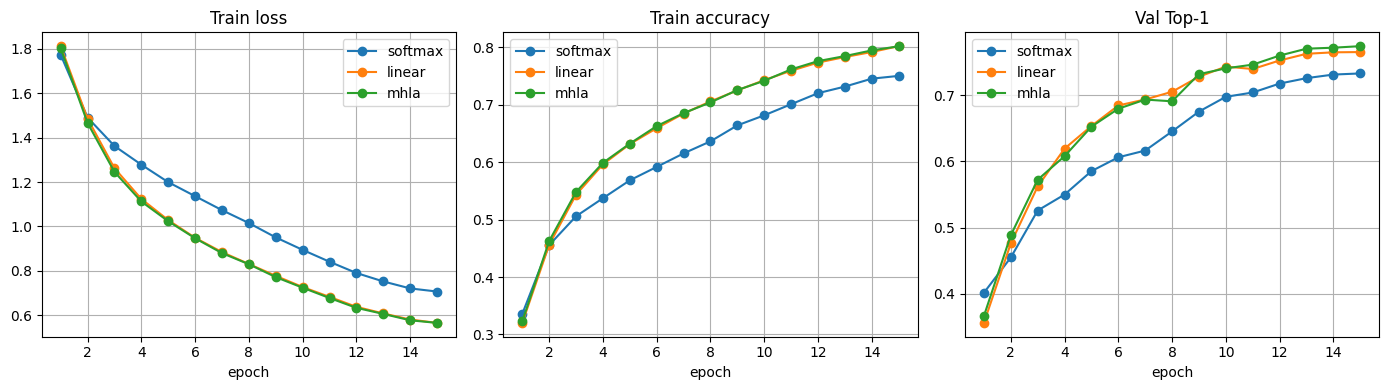

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
panels = [("train_loss", "Train loss"), ("train_acc", "Train accuracy"), ("val_top1", "Val Top-1")]
for ax, (key, title) in zip(axes, panels):
    for attn_type, h in history.items():
        ax.plot(range(1, len(h[key]) + 1), h[key], marker="o", label=attn_type)
    ax.set_xlabel("epoch")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()

In [30]:
print(f"{'mechanism':10s} {'params':>10s} {'best@1':>8s} {'best@5':>8s} {'epoch_s':>8s}")
for attn_type in ["softmax", "linear", "mhla"]:
    h = history[attn_type]
    p = count_params(models[attn_type])
    print(f"{attn_type:10s} {p:>10,} {max(h['val_top1']):>8.3f} "
          f"{max(h['val_top5']):>8.3f} {np.mean(h['epoch_time']):>8.1f}")

mechanism      params   best@1   best@5  epoch_s
softmax     1,212,106    0.733    0.984     17.0
linear      1,212,106    0.765    0.988     16.3
mhla        1,213,130    0.774    0.989     31.1


### Анализ выразительности матриц внимания

На фиксированном тестовом батче беру первый блок внимания каждой модели и восстанавливаю $N\times N$. Потолок ранга $\mathrm{rank}\le d_h$ - свойство одной головы - ранговые метрики считаю по каждой голове и усредняю.


In [31]:
def effective_rank(sigmas, eps=1e-12):
    s = sigmas[sigmas > eps]
    p = s / s.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def numeric_rank(sigmas, rel=1e-3):
    return int((sigmas > rel * sigmas[0]).sum())

def row_entropy(A, eps=1e-12):
    A = A / A.sum(axis=1, keepdims=True).clip(min=eps)
    H = -(A * np.log(A + eps)).sum(axis=1)
    return float(H.mean())

def gini(x):
    x = np.sort(np.abs(x))
    n = x.size
    idx = np.arange(1, n + 1)
    return float((2 * (idx * x).sum() / (n * x.sum())) - (n + 1) / n)


@torch.no_grad()
def first_attn_per_head(model, x):
    model.eval()
    h = model.patch_embed(x).flatten(2).transpose(1, 2) + model.pos_embed
    blk = model.blocks[0]
    return blk.attn.attention_matrix(blk.norm1(h), per_head=True)


sample_x = next(iter(test_loader))[0][:32].to(device)
spectra = {}
print(f"{'mechanism':10s} {'erank':>8s} {'num_rank':>9s} {'row_ent':>9s} {'gini_sv':>9s}")
for attn_type in ["softmax", "linear", "mhla"]:
    A = first_attn_per_head(models[attn_type], sample_x).cpu().numpy()
    A = A.reshape(-1, A.shape[-2], A.shape[-1])
    eranks, nranks, ents, ginis, svs = [], [], [], [], []
    for mat in A:
        sv = np.linalg.svd(mat, compute_uv=False)
        eranks.append(effective_rank(sv))
        nranks.append(numeric_rank(sv))
        ents.append(row_entropy(mat))
        ginis.append(gini(sv))
        svs.append(sv)
    spectra[attn_type] = np.mean(svs, axis=0)
    print(f"{attn_type:10s} {np.mean(eranks):>8.2f} {np.mean(nranks):>9.2f} "
          f"{np.mean(ents):>9.3f} {np.mean(ginis):>9.3f}")
print(f"\nhead_dim d_h = {CONFIG['dim'] // CONFIG['n_heads']},  N = {CONFIG['n_patches']},  "
      f"M = {CONFIG['n_blocks']},  потолок ранга: linear<=d_h, MHLA<=min(N, M*d_h)")

mechanism     erank  num_rank   row_ent   gini_sv
softmax       16.72     47.91     2.788     0.800
linear         2.60     13.19     3.959     0.965
mhla           6.76     33.36     3.935     0.905

head_dim d_h = 32,  N = 64,  M = 16,  потолок ранга: linear<=d_h, MHLA<=min(N, M*d_h)


### Спектр сингулярных значений

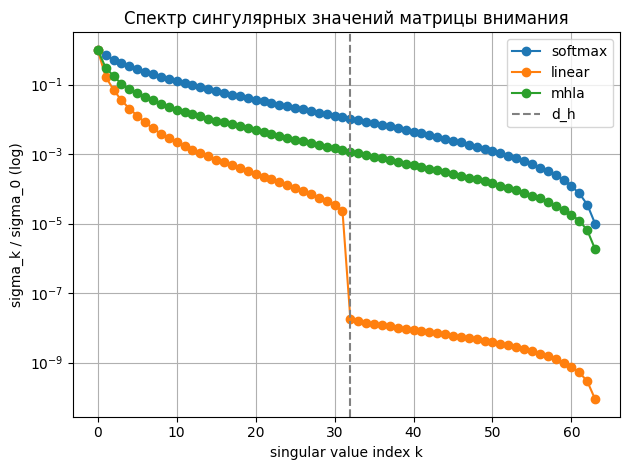

In [32]:
plt.figure()
for attn_type, sv in spectra.items():
    plt.semilogy(sv / sv[0], marker="o", label=attn_type)
plt.axvline(CONFIG["dim"] // CONFIG["n_heads"], color="gray", ls="--", label="d_h")
plt.xlabel("singular value index k")
plt.ylabel("sigma_k / sigma_0 (log)")
plt.title("Спектр сингулярных значений матрицы внимания")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Тепловые карты внимания, матрица смешивания

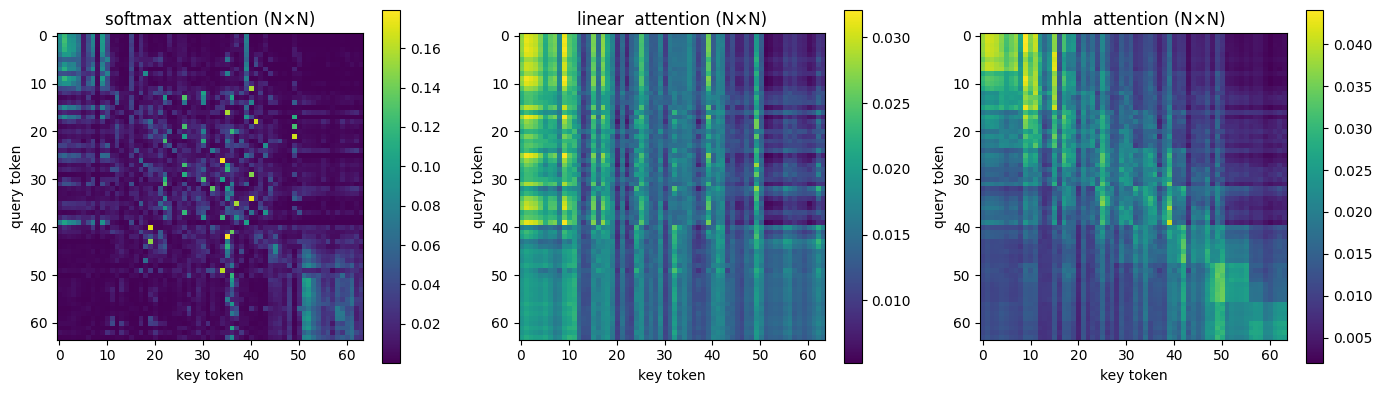

In [33]:
@torch.no_grad()
def first_attn_avg(model, x):
    model.eval()
    h = model.patch_embed(x).flatten(2).transpose(1, 2) + model.pos_embed
    blk = model.blocks[0]
    return blk.attn.attention_matrix(blk.norm1(h))


one_x = sample_x[:1]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, attn_type in zip(axes, ["softmax", "linear", "mhla"]):
    A = first_attn_avg(models[attn_type], one_x)[0].cpu().numpy()
    im = ax.imshow(A)
    ax.set_title(f"{attn_type}  attention (N×N)")
    ax.set_xlabel("key token")
    ax.set_ylabel("query token")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

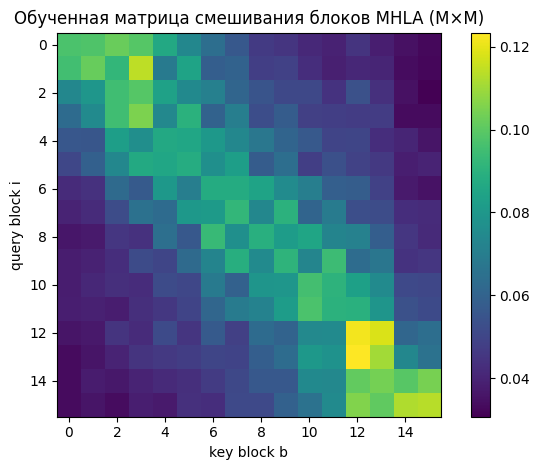

In [34]:
mhla_attn = models["mhla"].blocks[0].attn
Mc = mhla_attn.mixing_matrix().detach().cpu().numpy()
plt.figure()
im = plt.imshow(Mc)
plt.colorbar(im)
plt.title("Обученная матрица смешивания блоков MHLA (M×M)")
plt.xlabel("key block b")
plt.ylabel("query block i")
plt.tight_layout()
plt.show()

### Скорость при разных forward-pass по длине последовательности

In [35]:
def sync():
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


@torch.no_grad()
def bench(module, N, dim, warmup=10, iters=50):
    module.eval()
    x = torch.randn(1, N, dim, device=device)
    for _ in range(warmup):
        module(x)
    sync()
    t0 = time.time()
    for _ in range(iters):
        module(x)
    sync()
    return (time.time() - t0) / iters * 1e3


dim = CONFIG["dim"]
Ns = [64, 256, 1024, 4096, 16384]
bench_modules = {
    "softmax": SoftmaxAttention(dim, n_heads=6).to(device),
    "linear": VanillaLinearAttention(dim, n_heads=6).to(device),
    "mhla": MHLA(dim, n_heads=6, n_blocks=16).to(device),
}
timings = {name: [] for name in bench_modules}
for name, mod in bench_modules.items():
    for N in Ns:
        if name == "softmax" and N > 4096:
            timings[name].append(np.nan)
            continue
        timings[name].append(bench(mod, N, dim))
        print(f"{name:8s} N={N:6d}  {timings[name][-1]:8.3f} ms")

softmax  N=    64     0.560 ms
softmax  N=   256     0.600 ms
softmax  N=  1024     4.060 ms
softmax  N=  4096     3.540 ms
linear   N=    64     1.000 ms
linear   N=   256     1.060 ms
linear   N=  1024     1.060 ms
linear   N=  4096     0.980 ms
linear   N= 16384     1.000 ms
mhla     N=    64     1.700 ms
mhla     N=   256     1.720 ms
mhla     N=  1024     1.720 ms
mhla     N=  4096     1.720 ms
mhla     N= 16384     1.720 ms


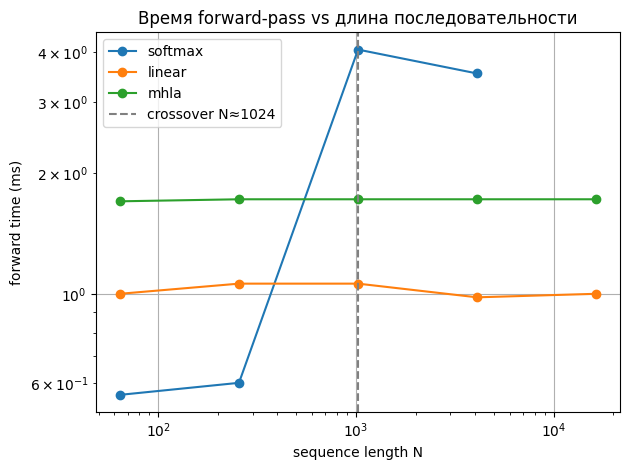

MHLA быстрее softmax начиная с N = 1024


In [36]:
plt.figure()
for name, ts in timings.items():
    ts = np.array(ts, dtype=float)
    mask = ~np.isnan(ts)
    plt.loglog(np.array(Ns)[mask], ts[mask], marker="o", label=name)

soft = np.array(timings["softmax"], dtype=float)
mhla = np.array(timings["mhla"], dtype=float)
cross = [Ns[i] for i in range(len(Ns)) if not np.isnan(soft[i]) and mhla[i] < soft[i]]
if cross:
    plt.axvline(cross[0], color="gray", ls="--", label=f"crossover N≈{cross[0]}")
plt.xlabel("sequence length N")
plt.ylabel("forward time (ms)")
plt.title("Время forward-pass vs длина последовательности")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print("MHLA быстрее softmax начиная с N =", cross[0] if cross else "> измеренного диапазона")

### Выводы

При равном числе параметров softmax и linear по 1 212 106, MHLA 1 213 130, и одинаковых условиях 15 эпох, общий seed, AdamW, cosine LR, на CIFAR-10 $N=64$:

| механизм | val Top-1 | Top-5 | erank | числ. ранг | энтропия строк | Gini | эпоха, s | forward N=1024, ms |
|---|---|---|---|---|---|---|---|---|
| softmax | 0.733 | 0.984 | 16.72 | 47.91 | 2.788 | 0.800 | 16-17 | 4.06 |
| linear | 0.765 | 0.988 | 2.60 | 13.19 | 3.959 | 0.965 | 16-17 | 1.0 |
| mhla | 0.774 | 0.989 | 6.76 | 33.36 | 3.935 | 0.905 | 31 | 1.72 |


MHLA лучший топ1 с небольшим отрывом от linear. MHLA выигрывает на длинных последовательностях, где linear проигрывает